## This Notebook gives an example on how plot estimated CAG expansion and Aggregate correlation in single cells (Figure 5 and Supplementary Figure 15 in the manuscript)

In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

In [2]:
adata=sc.read_h5ad('adata/Dryad/adata_AGG_CAG.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 185721 × 1128
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CAG', 'nHTT', 'vol_nuc', 'sample', 'HD', 'patient', 'batch', 'cluster_names', 'Agg', 'Agg_bright', 'Agg_vol', 'Agg_x', 'Agg_y', 'Agg_z', 'Agg_dist', 'cluster_general', 'lipo', 'm_gamma', 'v_gamma', 'm_h3k9', 'm_h3k27'
    obsm: 'X_pca', 'X_pca_harmony', 'X_raw', 'X_spatial', 'X_umap'

In [4]:
#Estimated Mean CAG

adata.obs['CAG_length'] = [
    (cag_level - 0.0464) / 0.0024 if batch == 'Aug' else (cag_level - 0.0462) / 0.003
    for cag_level, batch in zip(adata.obs['CAG'], adata.obs['batch'])
]

In [5]:
wt_allele = {
    "C1": 30, "C3": 19, "C4": 19, "C5": 17,
    "H1": 22, "H2": 20, "H3": 19, "H4": 20, "H5": 19
}

In [6]:
#Estimated Mutant CAG

for pt in adata.obs['patient'].unique():
    if pt in wt_allele:
        mask = adata.obs['patient'] == pt
        adata.obs.loc[mask, "CAG_mut"] = (
            adata.obs.loc[mask, "CAG_length"] * 2 - wt_allele[pt]
        )

In [7]:
##################################################
#### FIGURE 5B: Percent of cells with Aggregates and/or CAG expansion >140
##################################################

In [8]:
adata.obs['Expansion'] = adata.obs['CAG_mut'] >= 150
adata.obs['Expansion'] = adata.obs['Expansion'].apply(lambda x: True if x else False)

In [9]:
HTT_5 = adata[adata.obs['nHTT'] > 5]
Neuron_HD = HTT_5[(HTT_5.obs['cluster_general'].isin(['Excitatory Neurons', 'Inhibitory Neurons'])) & 
    (HTT_5.obs['HD']==True)].copy()

In [10]:
cluster_order = [ "L2.IT", "L3.IT","L4.IT",'L5.IT', 'L5.ET', "L5.6.NP",'L6.IT', 'L6.Car3', "L6.CT",'L6b',"Chandelier","LAMP5","PVALB", "SNCG",'VIP', "SST" ]

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55340/902355108.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  condition_counts = data_df.groupby(['cluster_names', 'Condition']).size().unstack(fill_value=0)


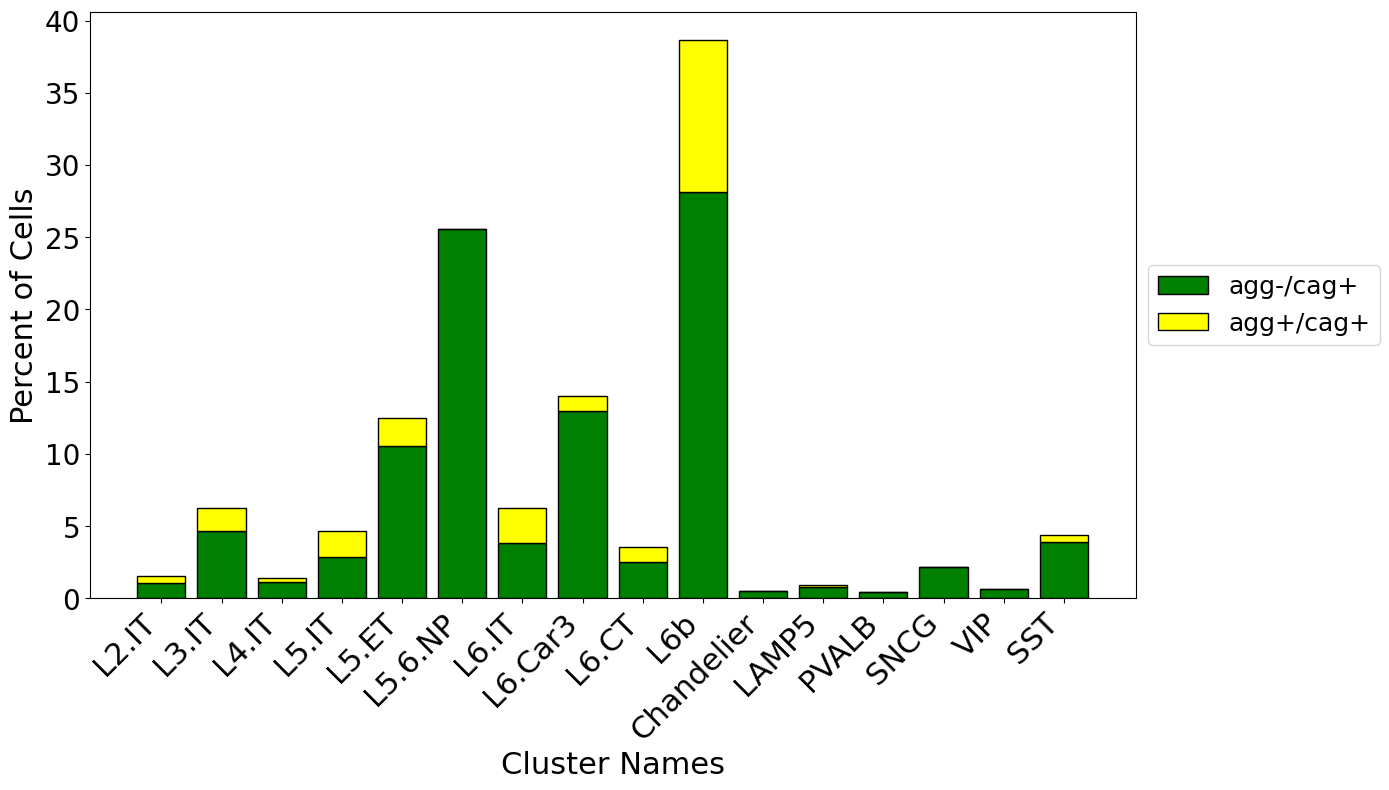

In [11]:
data_df = Neuron_HD.obs[['Agg', 'Expansion', 'cluster_names','patient','CAG_length']].copy()

data_df['Agg'] = data_df['Agg'].fillna(False).astype('bool')
data_df['Expansion'] = pd.to_numeric(data_df['Expansion'], errors='coerce')
data_df['Expansion'] = data_df['Expansion'].fillna(False)

data_df['Condition'] = 'agg-/cag-'  # Default
data_df.loc[(data_df['Agg']) & (data_df['Expansion']), 'Condition'] = 'agg+/cag+'
data_df.loc[(data_df['Agg']) & (~data_df['Expansion']), 'Condition'] = 'agg+/cag-'
data_df.loc[(~data_df['Agg']) & (data_df['Expansion']), 'Condition'] = 'agg-/cag+'

condition_counts = data_df.groupby(['cluster_names', 'Condition']).size().unstack(fill_value=0)
total_counts = condition_counts.sum(axis=1)
percentages = (condition_counts.T / total_counts).T * 100

percentages = percentages.loc[cluster_order]
clusters = percentages.index
conditions = [ 'agg-/cag+','agg+/cag+']  # Reverse order for plotting
bar_width = 0.8
index = np.arange(len(clusters))


colors = {
    'agg-/cag-': 'grey',
    'agg+/cag-': 'magenta',
    'agg-/cag+': 'green',
    'agg+/cag+': 'yellow'
}

plt.figure(figsize=(14, 8))

bottoms = np.zeros(len(clusters))
for condition in conditions:
    plt.bar(index, percentages[condition], bar_width, bottom=bottoms, label=condition, color=colors[condition], edgecolor='black')
    bottoms += percentages[condition]

plt.title('', fontsize=25)
plt.xlabel('Cluster Names', fontsize=22)
plt.ylabel('Percent of Cells', fontsize=22)
plt.xticks(index, clusters, fontsize=22, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=18)

plt.tight_layout()
plt.savefig('Figures/F5B.pdf')
plt.show()


In [12]:
##################################################
#### FIGURE 5C: CAG length in Excitatory Neurons with Intranuclear Aggregates
##################################################

In [13]:
HD_Exc = HTT_5[(HTT_5.obs['cluster_general']=='Excitatory Neurons') & 
    (HTT_5.obs['HD']==True)].copy()

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


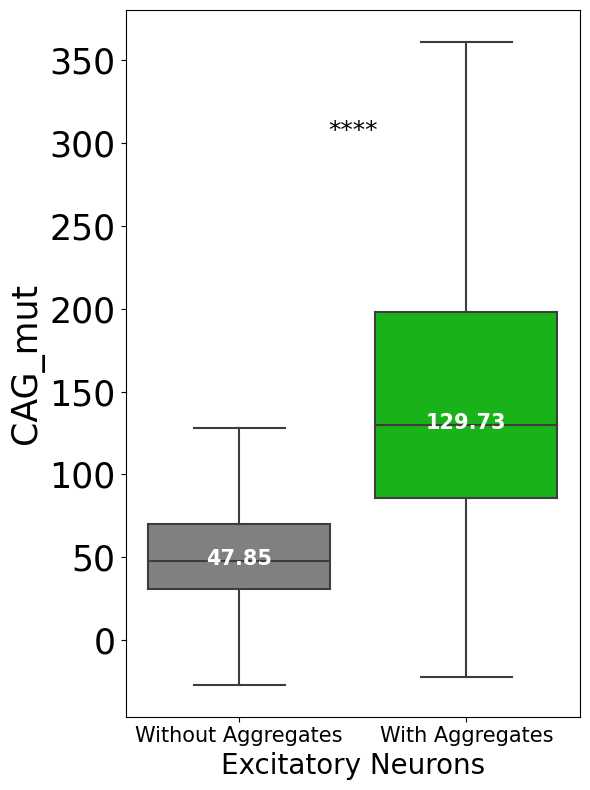

In [14]:
data_df = HD_Exc.obs[['Agg','CAG_mut' ,'nHTT','cluster_names','total_counts']].copy()
agg_mask = data_df['Agg'] == True
with_agg = data_df[agg_mask]['CAG_mut']
without_agg = data_df[~agg_mask]['CAG_mut']


t_stat, p_val = stats.ttest_ind(with_agg, without_agg, equal_var=False, nan_policy='omit')

plot_df = pd.DataFrame({
    'CAG_mut': np.concatenate([without_agg, with_agg]),
    'Aggregation': ['Without Aggregates'] * len(without_agg) + ['With Aggregates'] * len(with_agg)
})

plt.figure(figsize=(6, 8))
ax = sns.boxplot(x='Aggregation', y='CAG_mut', data=plot_df, order=['Without Aggregates', 'With Aggregates'], palette=['grey','#00cc00'], showfliers=False)

agg_medians = plot_df.groupby('Aggregation')['CAG_mut'].median()
agg_sems = plot_df.groupby('Aggregation')['CAG_mut'].sem()


positions = {'Without Aggregates': 0, 'With Aggregates': 1} 

for status, position in positions.items():
    median = agg_medians[status]
    sem = agg_sems[status]
    plt.text(position, median-5, f'{median:.2f}', ha='center', va='bottom', fontsize=15, color='white', weight='bold')


if p_val < 0.05:
    significance = '*'
    if p_val < 0.01:
        significance = '**'
    if p_val < 0.001:
        significance = '***'
    if p_val < 0.0001:
        significance = '****'
    plt.text(0.5, 300, significance, ha='center', va='bottom', fontsize=18)

plt.xlabel('Excitatory Neurons', fontsize=20)
plt.ylabel('CAG_mut', fontsize=25)
plt.xticks(fontsize=15)
plt.yticks(fontsize=25)

plt.tight_layout()
plt.savefig('Figures/F5C.pdf')
plt.show()



In [15]:
##################################################
#### SUPPLEMENTARY FIGURE 15A: CAG length in Excitatory Neurons with Intranuclear Aggregates by donor
##################################################

In [16]:
upatientHD=HD_Exc.obs['patient'].unique()

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


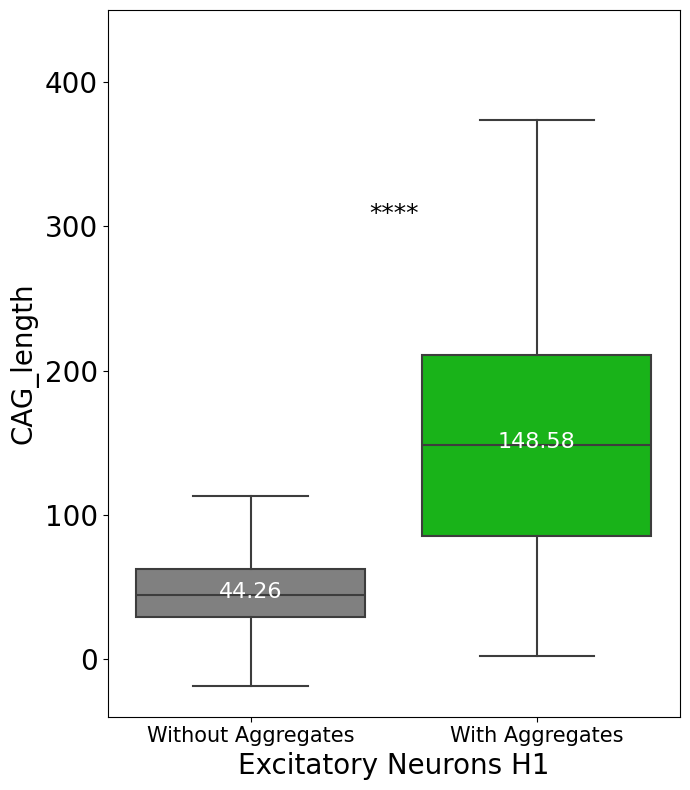

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


H1


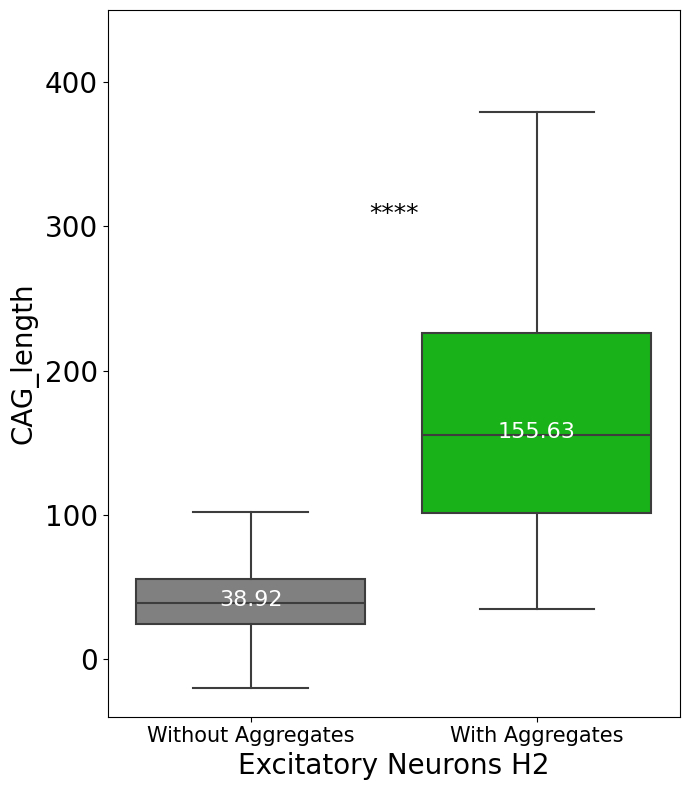

H2


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


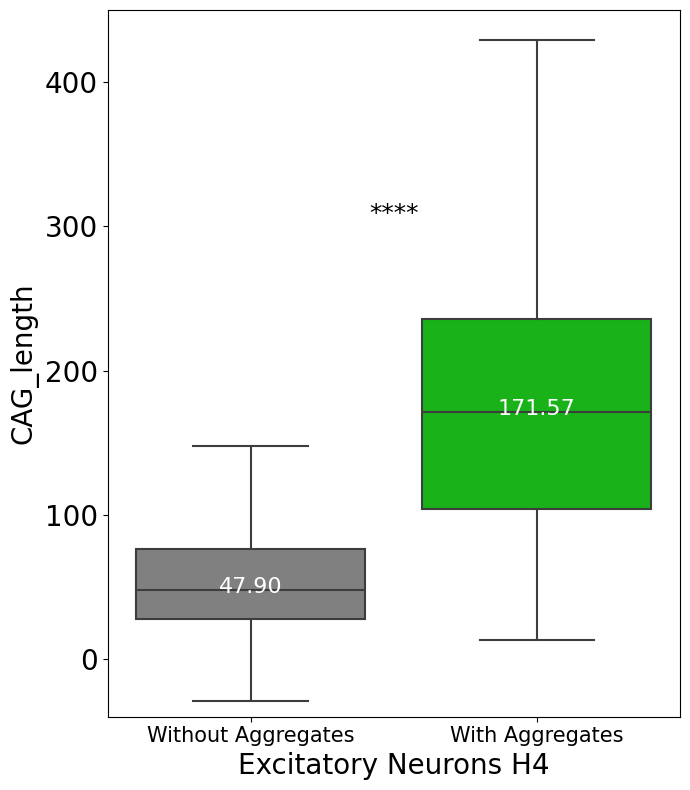

H4


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


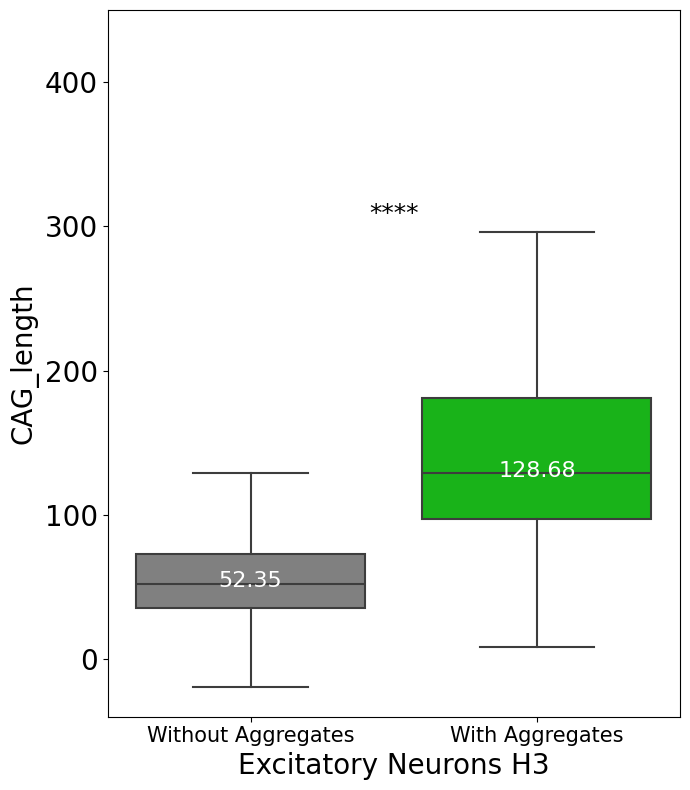

H3


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


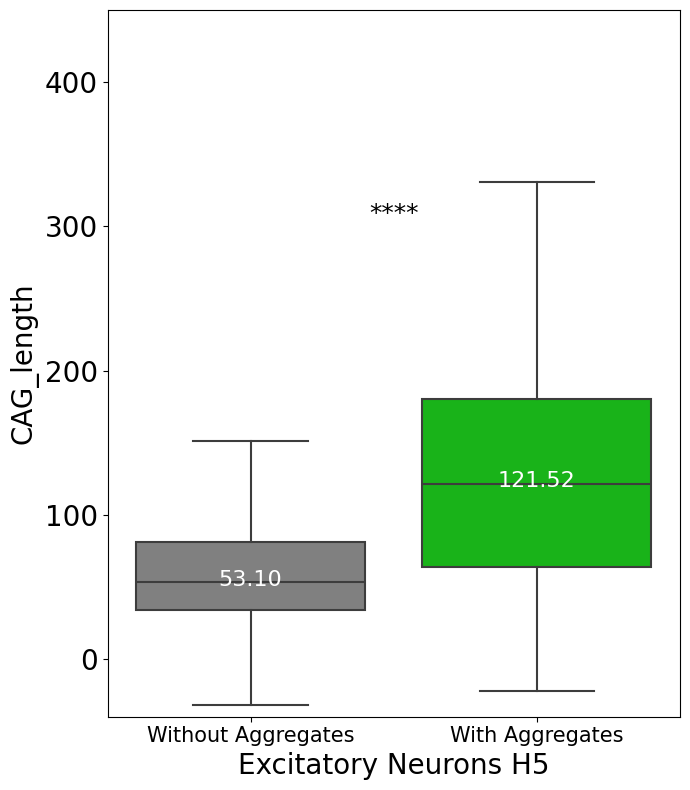

H5


In [17]:
for pt in upatientHD:
    sorted_df = HD_Exc.obs[['patient','Agg','CAG_mut' ,'nHTT','cluster_names','total_counts']].copy()
    data_df = sorted_df[sorted_df['patient']==pt].copy()
    agg_mask = data_df['Agg'] == True
    with_agg = data_df[agg_mask]['CAG_mut']
    without_agg = data_df[~agg_mask]['CAG_mut']
    
    
    t_stat, p_val = stats.ttest_ind(with_agg, without_agg, equal_var=False, nan_policy='omit')
    
    plot_df = pd.DataFrame({
        'CAG_mut': np.concatenate([without_agg, with_agg]),
        'Aggregation': ['Without Aggregates'] * len(without_agg) + ['With Aggregates'] * len(with_agg)
    })
    
    
    plt.figure(figsize=(7, 8))
    ax = sns.boxplot(x='Aggregation', y='CAG_mut', data=plot_df, order=['Without Aggregates', 'With Aggregates'], palette=['grey','#00cc00'], showfliers=False)
    
    # Calculate meadins and SEMs
    agg_medians = plot_df.groupby('Aggregation')['CAG_mut'].median()
    agg_sems = plot_df.groupby('Aggregation')['CAG_mut'].sem()
    
    
    positions = {'Without Aggregates': 0, 'With Aggregates': 1}  # Dictionary to map aggregation status to plot positions
    
    for status, position in positions.items():
        median = agg_medians[status]
        sem = agg_sems[status]
        #plt.errorbar(position, mean, yerr=sem, fmt='none', c='black', capsize=5)
        plt.text(position, median-5, f'{median:.2f}', ha='center', va='bottom', fontsize=16, color='white')
    
    if p_val < 0.05:
        significance = '*'
        if p_val < 0.01:
            significance = '**'
        if p_val < 0.001:
            significance = '***'
        if p_val < 0.0001:
            significance = '****'
        plt.text(0.5, 300, significance, ha='center', va='bottom', fontsize=18)
    
    plt.xlabel(f'Excitatory Neurons {pt}', fontsize=20)
    plt.ylabel('CAG_length', fontsize=20)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=20)
    plt.ylim(-40,450)
    plt.savefig(f'Figures/SF15A_{pt}.pdf')
    
    plt.tight_layout()
    
    plt.show()
    print(pt)


In [18]:
##################################################
#### SUPPLEMENTARY FIGURE 15C: CAG length in Excitatory Neurons with Intranuclear Aggregates by cell type
##################################################

In [19]:
uclusters=HD_Exc.obs['cluster_names'].unique()

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


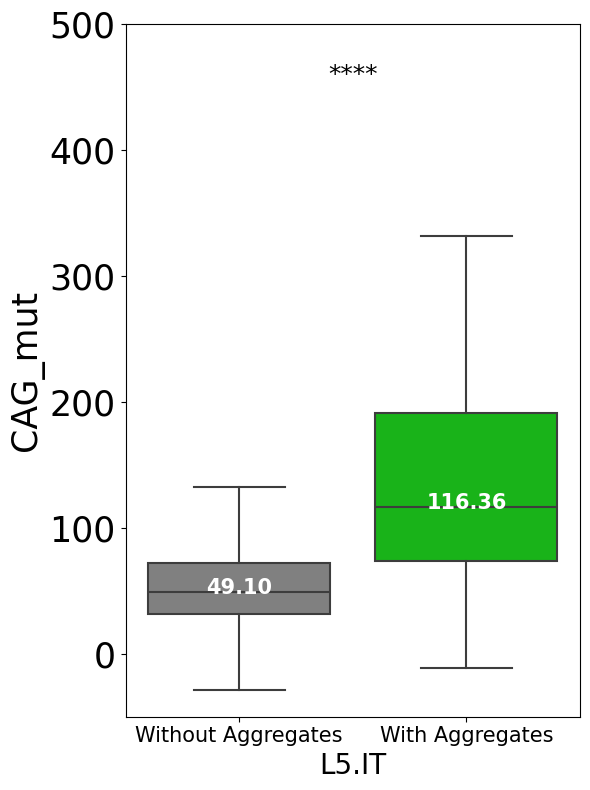

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


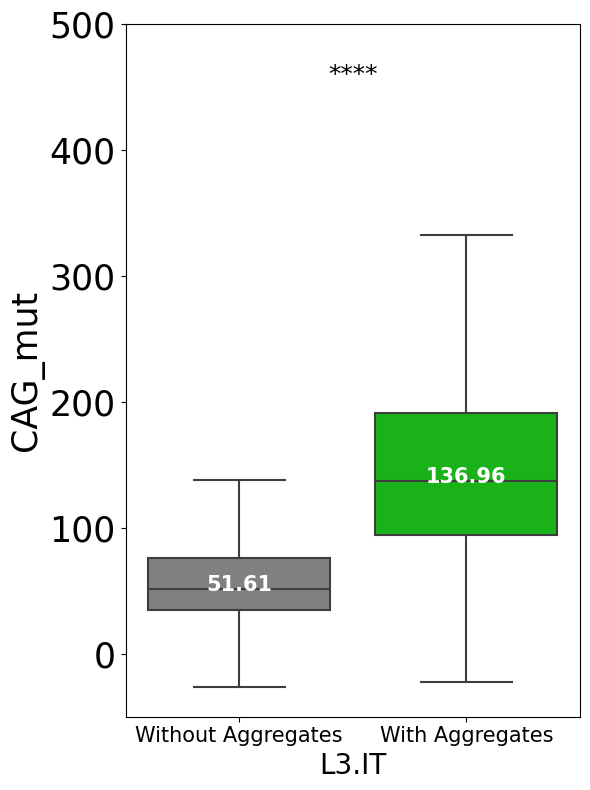

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


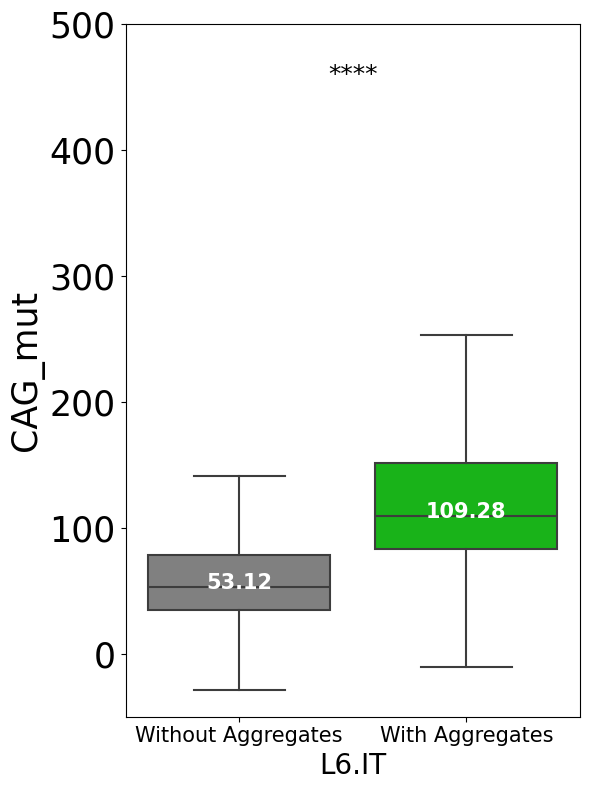

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


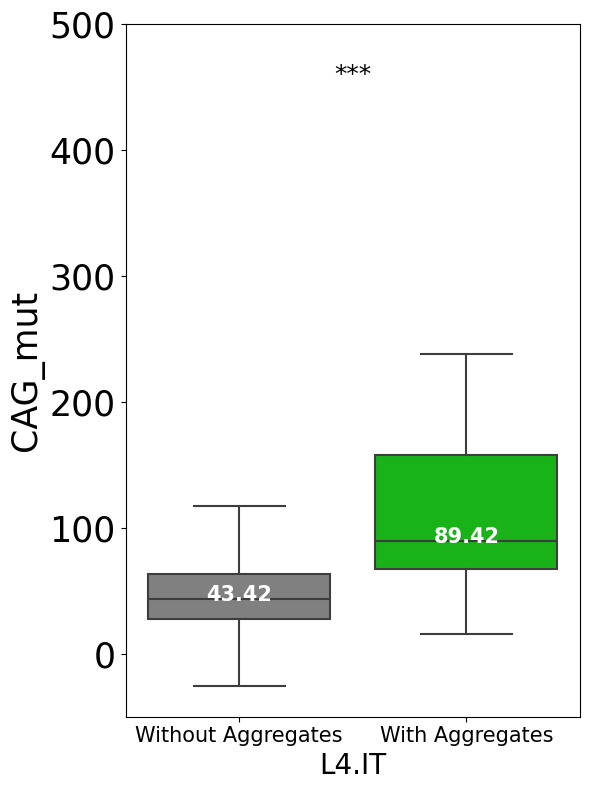

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


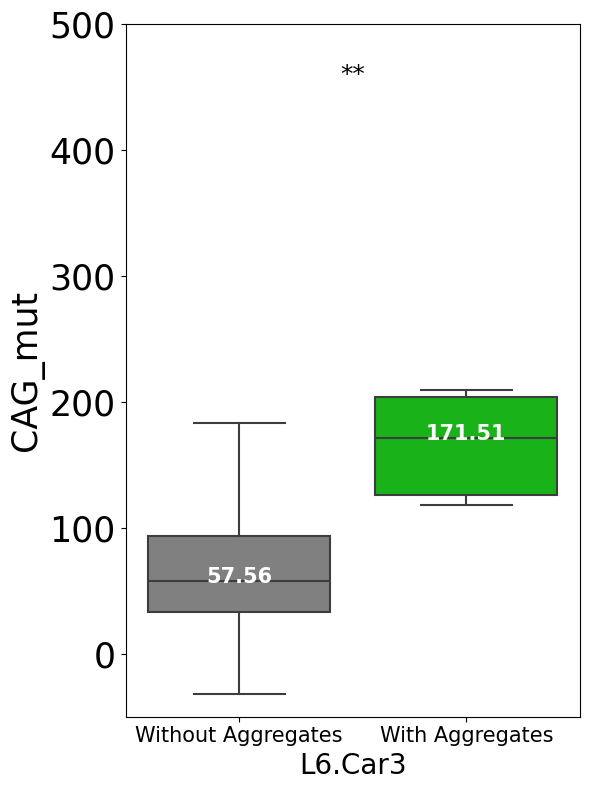

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


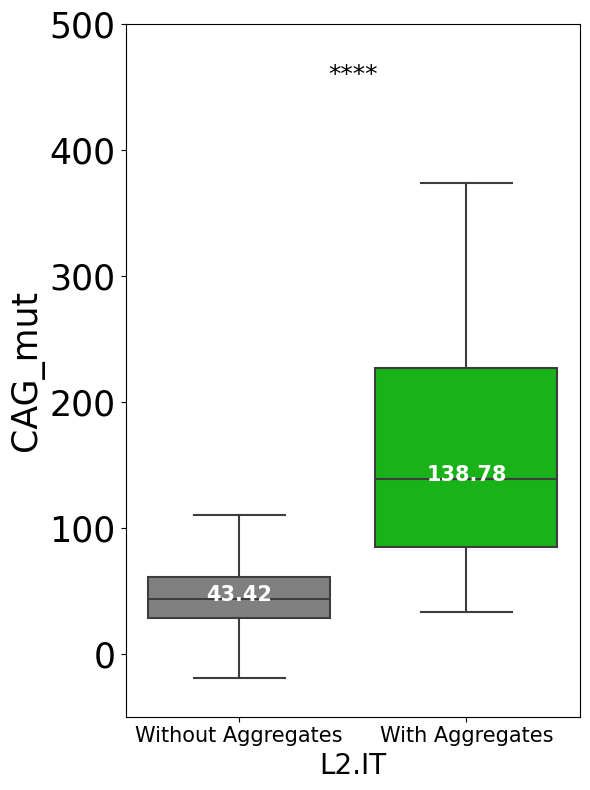

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


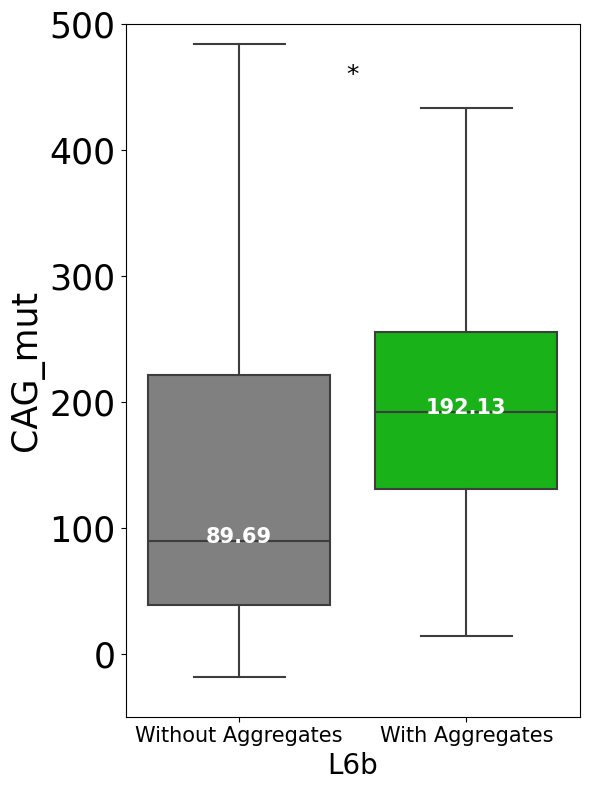

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


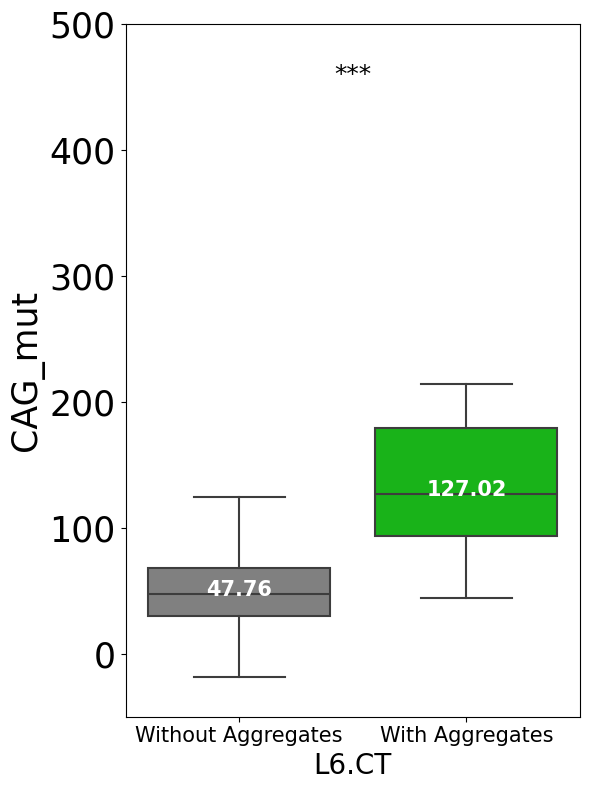

In [20]:
for ucl in uclusters:
    sadata_= HD_Exc[HD_Exc.obs['cluster_names']==ucl].copy()
    
    if len(sadata_[sadata_.obs['Agg']==True])<5:
        continue
    
    data_df = sadata_.obs[['Agg','CAG_mut' ,'nHTT','cluster_names','total_counts']].copy()
    agg_mask = data_df['Agg'] == True
    with_agg = data_df[agg_mask]['CAG_mut']
    without_agg = data_df[~agg_mask]['CAG_mut']
    
    
    t_stat, p_val = stats.ttest_ind(with_agg, without_agg, equal_var=False, nan_policy='omit')
    
    plot_df = pd.DataFrame({
        'CAG_mut': np.concatenate([without_agg, with_agg]),
        'Aggregation': ['Without Aggregates'] * len(without_agg) + ['With Aggregates'] * len(with_agg)
    })
    
    plt.figure(figsize=(6, 8))
    ax = sns.boxplot(x='Aggregation', y='CAG_mut', data=plot_df, order=['Without Aggregates', 'With Aggregates'], palette=['grey','#00cc00'], showfliers=False)
    
    agg_medians = plot_df.groupby('Aggregation')['CAG_mut'].median()
    agg_sems = plot_df.groupby('Aggregation')['CAG_mut'].sem()
    
    
    positions = {'Without Aggregates': 0, 'With Aggregates': 1}  # Dictionary to map aggregation status to plot positions
    
    for status, position in positions.items():
        median = agg_medians[status]
        sem = agg_sems[status]
        plt.text(position, median-5, f'{median:.2f}', ha='center', va='bottom', fontsize=15, color='white', weight='bold')
    
    
    if p_val < 0.05:
        significance = '*'
        if p_val < 0.01:
            significance = '**'
        if p_val < 0.001:
            significance = '***'
        if p_val < 0.0001:
            significance = '****'
        plt.text(0.5, 450, significance, ha='center', va='bottom', fontsize=18)
    else:
        significance = 'ns'
        plt.text(0.5, 450, significance, ha='center', va='bottom', fontsize=18)
        
    plt.xlabel(ucl, fontsize=20)
    plt.ylabel('CAG_mut', fontsize=25)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=25)
    plt.ylim(-50, 500)
    
    plt.tight_layout()
    plt.savefig(f'Figures/SF15B_{ucl}.pdf')
    
    plt.show()


In [21]:
##################################################
#### FIGURE 5D: Intranuclear Aggregates and CAG Expansion
##################################################

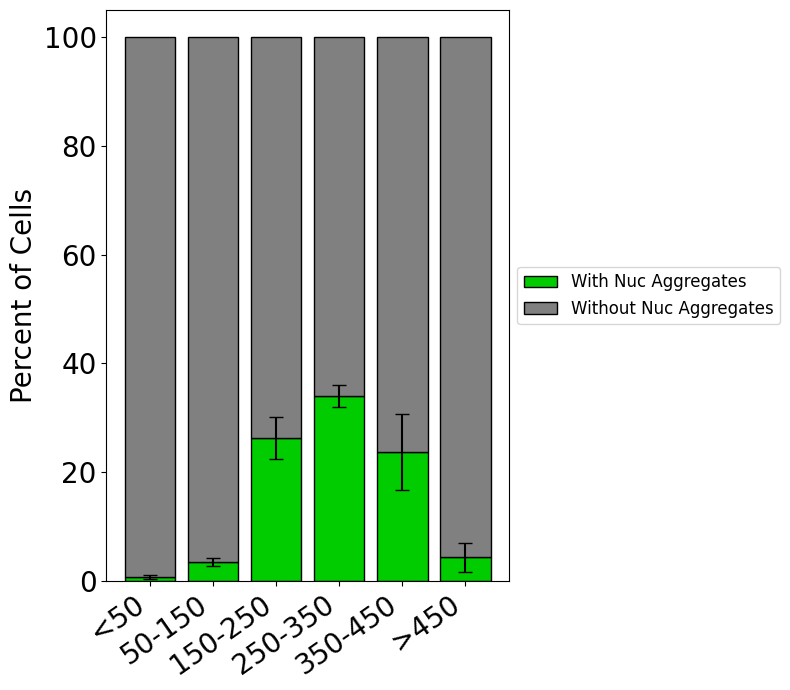

In [22]:
bins = [0, 50, 150, 250, 350, 450, np.inf]
bin_labels = ['<50', '50-150', '150-250', '250-350', '350-450', '>450']

agg_percent_matrix = []

for pt in upatientHD:
    sorted_df = HD_Exc.obs[['CAG_mut', 'Agg', 'patient']].copy()
    data_df = sorted_df[sorted_df['patient'] == pt].copy()

    data_df['Agg'] = data_df['Agg'].fillna(False).astype(bool)
    data_df['CAG_mut'] = pd.to_numeric(data_df['CAG_mut'], errors='coerce')
    data_df = data_df.dropna(subset=['CAG_mut'])

    ncells, _ = np.histogram(data_df['CAG_mut'], bins=bins)
    ncells_AGG, _ = np.histogram(data_df.loc[data_df['Agg'], 'CAG_mut'], bins=bins)

    with np.errstate(divide='ignore', invalid='ignore'):
        percent_cells_with_agg = 100 * (ncells_AGG / ncells)
        percent_cells_with_agg = np.nan_to_num(percent_cells_with_agg)

    agg_percent_matrix.append(percent_cells_with_agg)

agg_df = pd.DataFrame(agg_percent_matrix, columns=bin_labels, index=upatientHD)

mean_with_agg = agg_df.mean()
sem_with_agg = agg_df.sem()

mean_without_agg = 100 - mean_with_agg
sem_without_agg = agg_df.apply(lambda col: np.sqrt((col.std(ddof=1) ** 2) + (col.std(ddof=1) ** 2)) / np.sqrt(len(col)), axis=0)


plt.figure(figsize=(8, 7))
x = np.arange(len(bin_labels))
bar_width = 0.6

plt.bar(x, mean_with_agg, yerr=sem_with_agg, capsize=5, label='With Nuc Aggregates',
        color='#00cc00', edgecolor='black')

plt.bar(x, mean_without_agg, bottom=mean_with_agg, label='Without Nuc Aggregates',
        color='grey', edgecolor='black')

plt.xticks(x, bin_labels, fontsize=20, rotation=35, ha='right')
plt.yticks(fontsize=20)
plt.ylabel('Percent of Cells', fontsize=20)
plt.title('', fontsize=20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.tight_layout()
plt.savefig('Figures/F5E.pdf')
plt.show()


In [23]:
##################################################
#### SUPPLEMENTARY FIGURE 15B: Intranuclear Aggregates and CAG Expansion by donor
##################################################

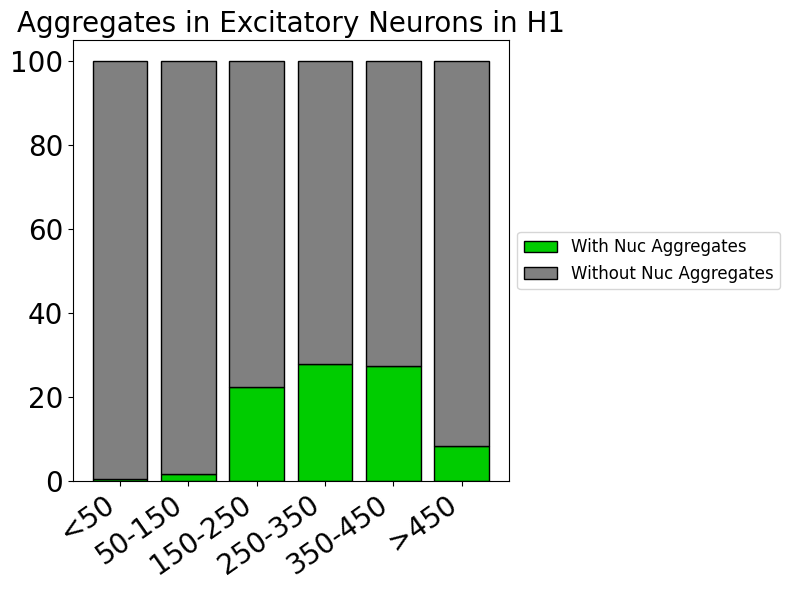

[1684 1143   58   18   11   12]
[ 5 17 13  5  3  1]
[ 0.29691211  1.48731409 22.4137931  27.77777778 27.27272727  8.33333333]
[99.70308789 98.51268591 77.5862069  72.22222222 72.72727273 91.66666667]


/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55340/2496849600.py:15: RuntimeWarning: invalid value encountered in divide
  percent_cells_with_agg = 100 * (ncells_AGG / ncells)


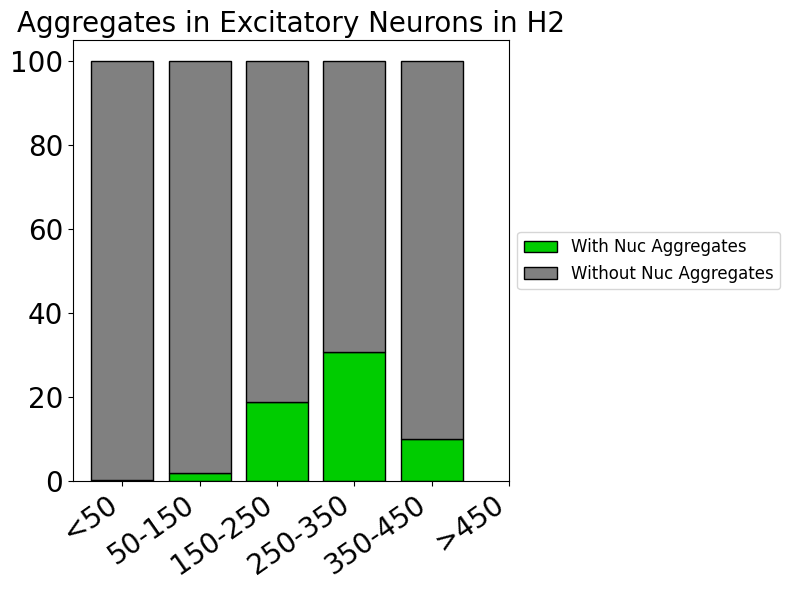

[1035  463   32   13   10    0]
[2 9 6 4 1 0]
[ 0.19323671  1.94384449 18.75       30.76923077 10.                 nan]
[99.80676329 98.05615551 81.25       69.23076923 90.                 nan]


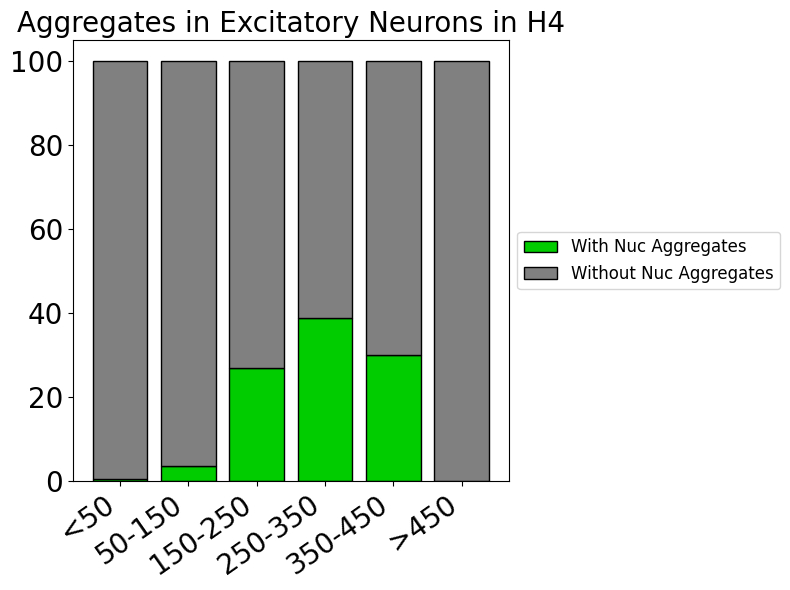

[665 601  67  18  10   8]
[ 3 21 18  7  3  0]
[ 0.45112782  3.49417637 26.86567164 38.88888889 30.          0.        ]
[ 99.54887218  96.50582363  73.13432836  61.11111111  70.
 100.        ]


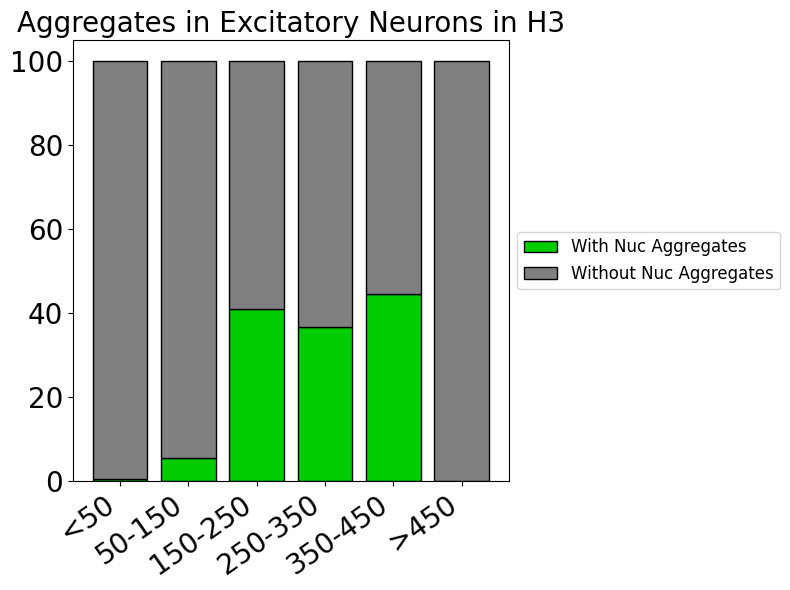

[1691 1948  120   30    9   11]
[  8 107  49  11   4   0]
[ 0.47309284  5.49281314 40.83333333 36.66666667 44.44444444  0.        ]
[ 99.52690716  94.50718686  59.16666667  63.33333333  55.55555556
 100.        ]


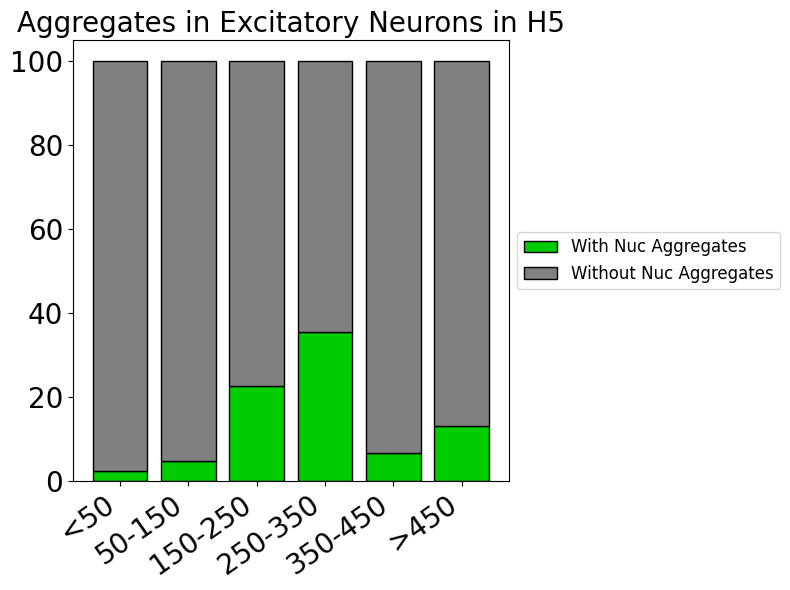

[1210 1367  159   31   15   23]
[28 63 36 11  1  3]
[ 2.31404959  4.60863204 22.64150943 35.48387097  6.66666667 13.04347826]
[97.68595041 95.39136796 77.35849057 64.51612903 93.33333333 86.95652174]


In [24]:
bins = [0, 50, 150, 250, 350, 450, np.inf]
bin_labels = ['<50', '50-150', '150-250', '250-350', '350-450', '>450']

for pt in upatientHD:
    sorted_df = HD_Exc.obs[['CAG_mut','Agg','patient']].copy()
    data_df = sorted_df[sorted_df['patient']==pt].copy()
    
    data_df['Agg'] = data_df['Agg'].fillna(False).astype('bool')
    data_df['CAG_mut'] = pd.to_numeric(data_df['CAG_mut'], errors='coerce')
    data_df = data_df.dropna(subset=['CAG_mut'])
    
    ncells, _ = np.histogram(data_df['CAG_mut'], bins=bins)
    ncells_AGG, _ = np.histogram(data_df.loc[data_df['Agg'], 'CAG_mut'], bins=bins)
    
    percent_cells_with_agg = 100 * (ncells_AGG / ncells)
    percent_cells_without_agg = 100 - percent_cells_with_agg
    
    bar_width = 0.8
    index = np.arange(len(bin_labels))
    
    plt.figure(figsize=(8, 6))
    plt.bar(index, percent_cells_with_agg, bar_width, label='With Nuc Aggregates', color='#00cc00', edgecolor='black')
    plt.bar(index, percent_cells_without_agg, bar_width, bottom=percent_cells_with_agg, label='Without Nuc Aggregates', color='grey', edgecolor='black')
    
    plt.title(f'Aggregates in Excitatory Neurons in {pt}', fontsize=20)
    #plt.xlabel('CAG Length', fontsize=20)
    #plt.ylabel('Percent of Cells', fontsize=20)
    plt.xticks(index, bin_labels, fontsize=20, rotation=35, ha='right')
    plt.yticks(fontsize=20)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
    
    # Display the plot
    plt.tight_layout()
    plt.savefig(f'Figures/SF15B_{pt}.pdf')
    plt.show()
    print(ncells)
    print(ncells_AGG)
    print (percent_cells_with_agg)
    print (percent_cells_without_agg)


In [25]:
##################################################
#### SUPPLEMENTARY FIGURE 15D: Intranuclear Aggregates and CAG Expansion by cell type
##################################################

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55340/3730784526.py:15: RuntimeWarning: invalid value encountered in divide
  percent_cells_with_agg = 100 * (ncells_AGG / ncells)


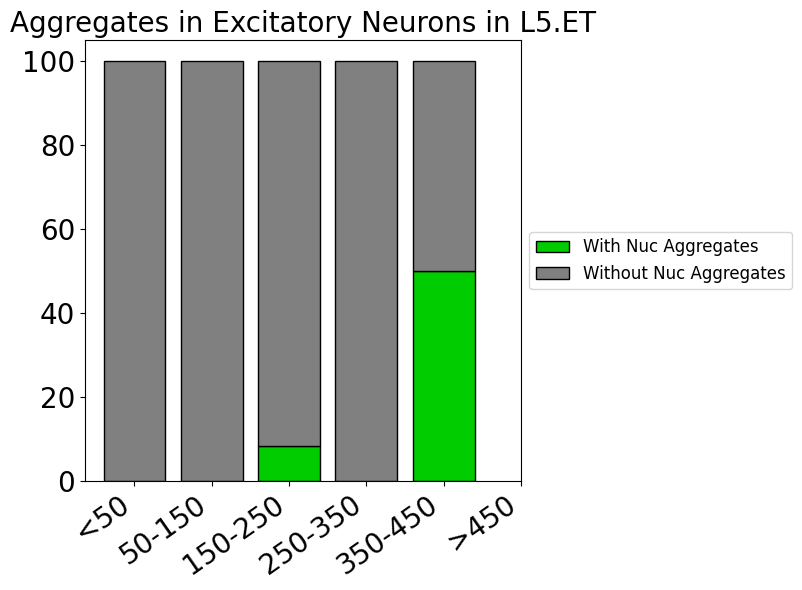

[69 59 12  3  4  0]
[0 0 1 0 2 0]
[ 0.          0.          8.33333333  0.         50.                 nan]
[100.         100.          91.66666667 100.          50.
          nan]


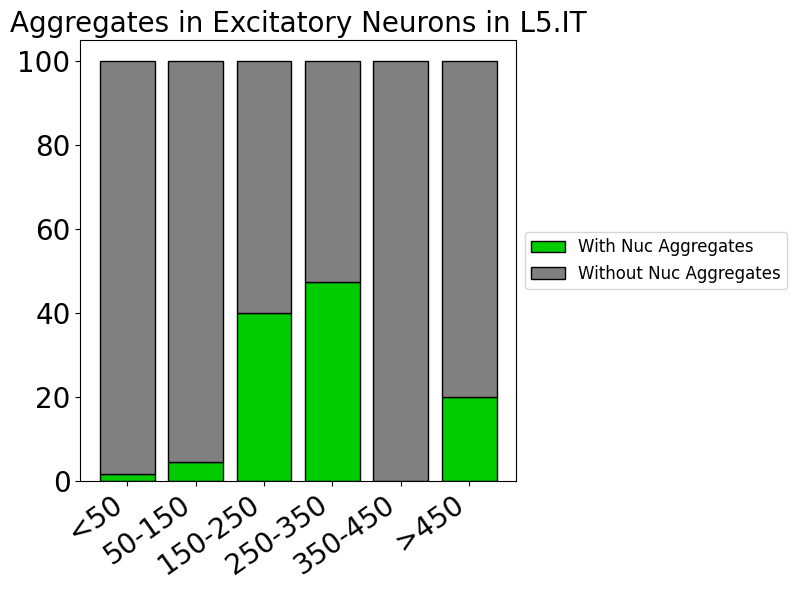

[931 911  65  19   4   5]
[14 41 26  9  0  1]
[ 1.5037594   4.50054885 40.         47.36842105  0.         20.        ]
[ 98.4962406   95.49945115  60.          52.63157895 100.
  80.        ]


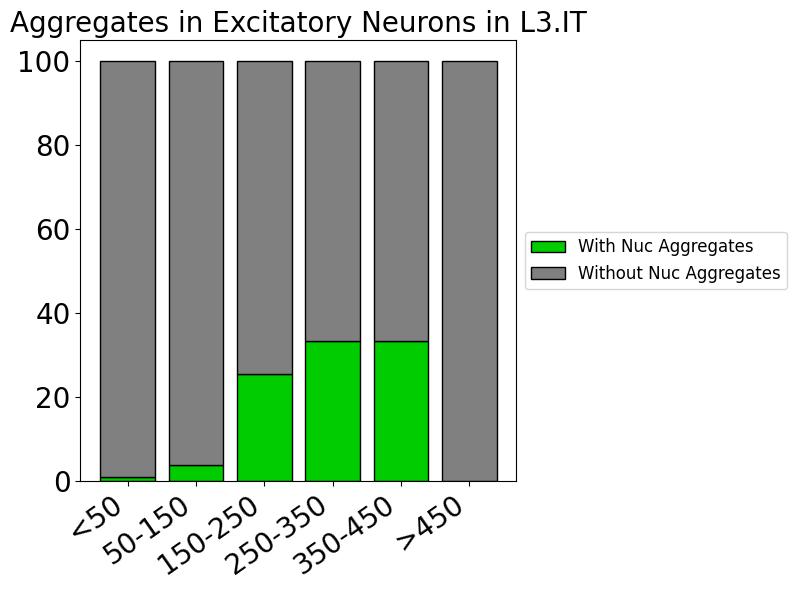

[1538 1620  153   33   12   17]
[13 62 39 11  4  0]
[ 0.84525358  3.82716049 25.49019608 33.33333333 33.33333333  0.        ]
[ 99.15474642  96.17283951  74.50980392  66.66666667  66.66666667
 100.        ]


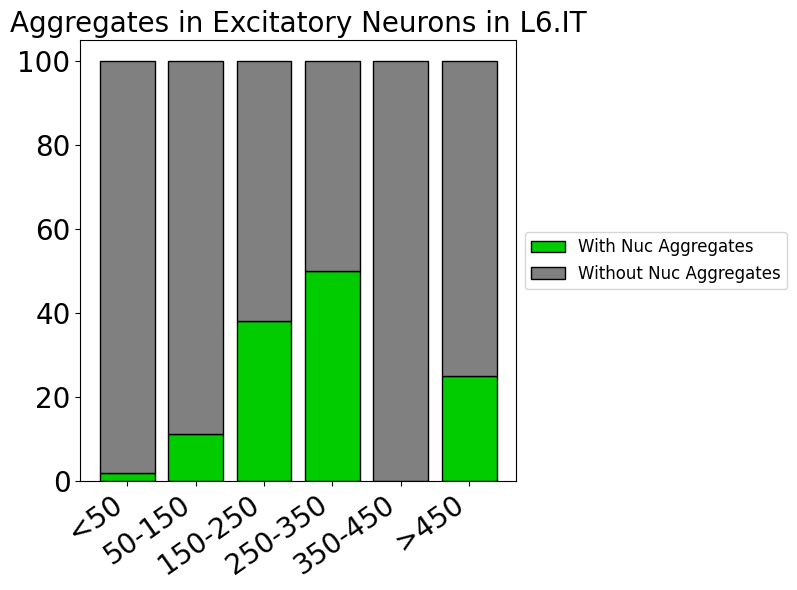

[446 554  55   8   1   4]
[ 8 62 21  4  0  1]
[ 1.79372197 11.19133574 38.18181818 50.          0.         25.        ]
[ 98.20627803  88.80866426  61.81818182  50.         100.
  75.        ]


/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55340/3730784526.py:15: RuntimeWarning: invalid value encountered in divide
  percent_cells_with_agg = 100 * (ncells_AGG / ncells)


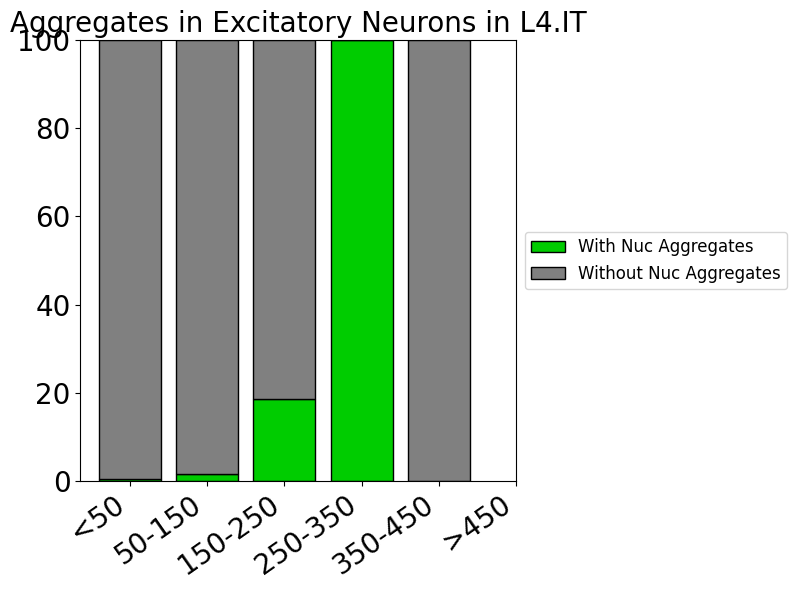

[1205  856   27    1    2    0]
[ 4 13  5  1  0  0]
[  0.33195021   1.51869159  18.51851852 100.           0.
          nan]
[ 99.66804979  98.48130841  81.48148148   0.         100.
          nan]


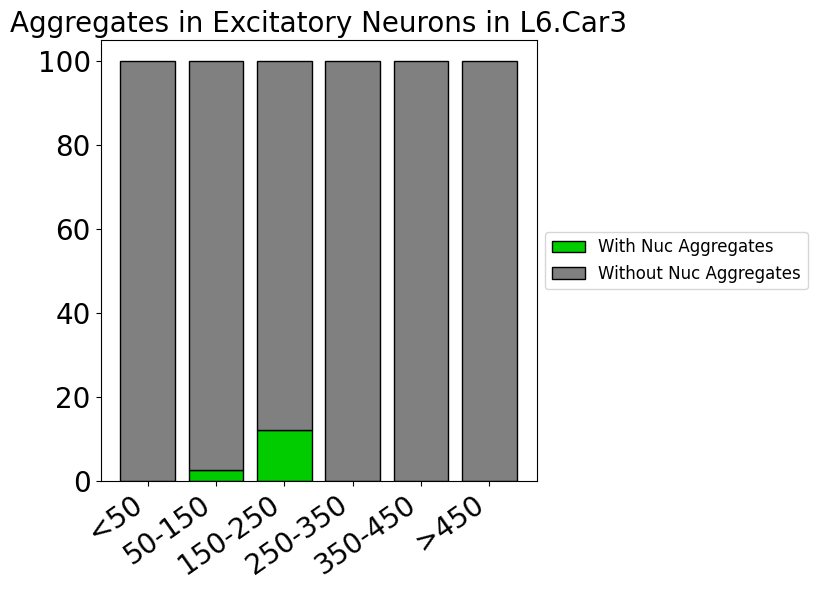

[114 120  25   4   6   5]
[0 3 3 0 0 0]
[ 0.   2.5 12.   0.   0.   0. ]
[100.   97.5  88.  100.  100.  100. ]


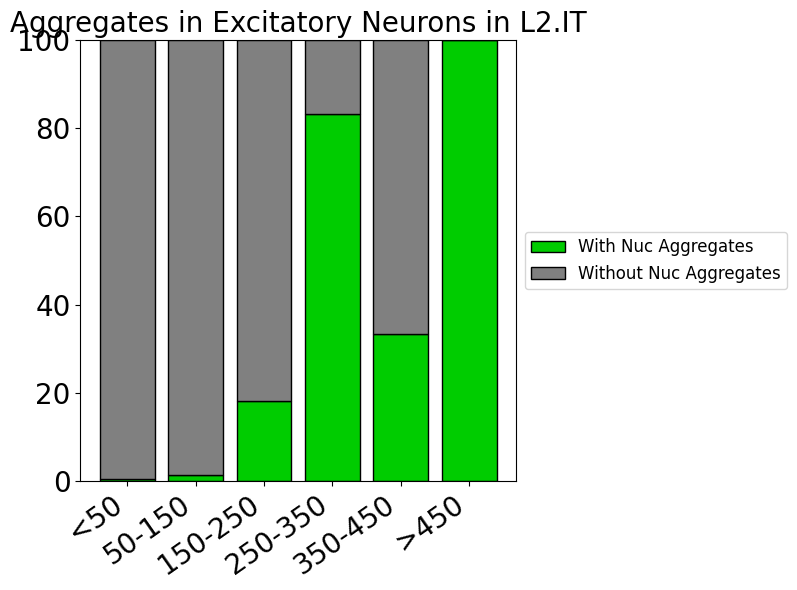

[1639 1076   33    6    3    2]
[ 5 14  6  5  1  2]
[  0.30506406   1.30111524  18.18181818  83.33333333  33.33333333
 100.        ]
[99.69493594 98.69888476 81.81818182 16.66666667 66.66666667  0.        ]


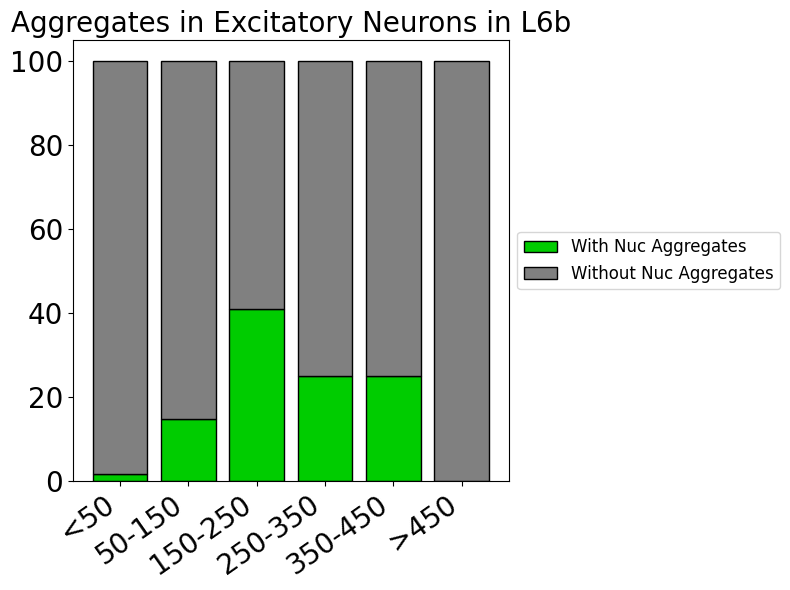

[67 89 39 32 20 15]
[ 1 13 16  8  5  0]
[ 1.49253731 14.60674157 41.02564103 25.         25.          0.        ]
[ 98.50746269  85.39325843  58.97435897  75.          75.
 100.        ]


/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55340/3730784526.py:15: RuntimeWarning: invalid value encountered in divide
  percent_cells_with_agg = 100 * (ncells_AGG / ncells)


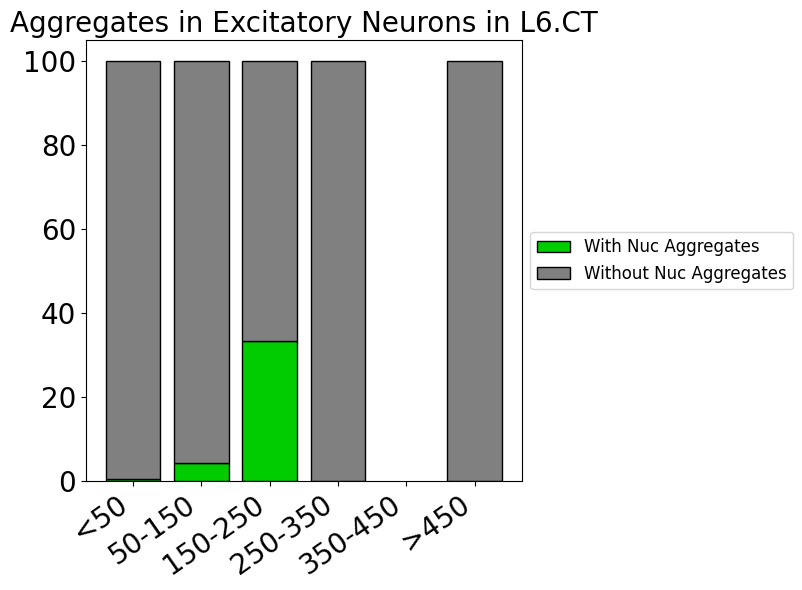

[238 215  15   1   0   1]
[1 9 5 0 0 0]
[ 0.42016807  4.18604651 33.33333333  0.                 nan  0.        ]
[ 99.57983193  95.81395349  66.66666667 100.                  nan
 100.        ]


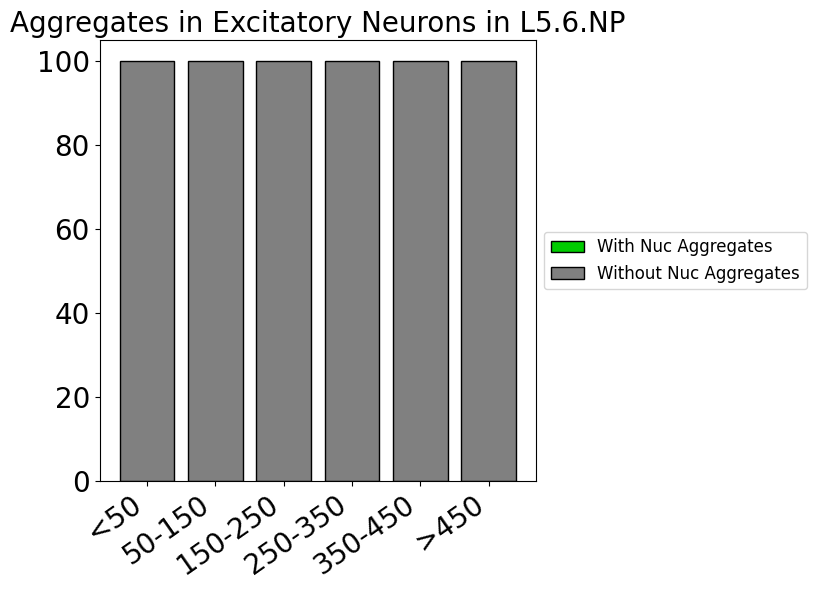

[38 22 12  3  3  5]
[0 0 0 0 0 0]
[0. 0. 0. 0. 0. 0.]
[100. 100. 100. 100. 100. 100.]


In [26]:
bins = [0, 50, 150, 250, 350, 450, np.inf]
bin_labels = ['<50', '50-150', '150-250', '250-350', '350-450', '>450']

for ucl in uclusters:
    sorted_df = HD_Exc.obs[['CAG_mut','Agg','cluster_names']].copy()
    data_df = sorted_df[sorted_df['cluster_names']==ucl].copy()
    
    data_df['Agg'] = data_df['Agg'].fillna(False).astype('bool')
    data_df['CAG_mut'] = pd.to_numeric(data_df['CAG_mut'], errors='coerce')
    data_df = data_df.dropna(subset=['CAG_mut'])
    
    ncells, _ = np.histogram(data_df['CAG_mut'], bins=bins)
    ncells_AGG, _ = np.histogram(data_df.loc[data_df['Agg'], 'CAG_mut'], bins=bins)
    
    percent_cells_with_agg = 100 * (ncells_AGG / ncells)
    percent_cells_without_agg = 100 - percent_cells_with_agg
    
    bar_width = 0.8
    index = np.arange(len(bin_labels))
    
    plt.figure(figsize=(8, 6))
    plt.bar(index, percent_cells_with_agg, bar_width, label='With Nuc Aggregates', color='#00cc00', edgecolor='black')
    plt.bar(index, percent_cells_without_agg, bar_width, bottom=percent_cells_with_agg, label='Without Nuc Aggregates', color='grey', edgecolor='black')
    
    plt.title(f'Aggregates in Excitatory Neurons in {ucl}', fontsize=20)
    #plt.xlabel('CAG Length', fontsize=20)
    #plt.ylabel('Percent of Cells', fontsize=20)
    plt.xticks(index, bin_labels, fontsize=20, rotation=35, ha='right')
    plt.yticks(fontsize=20)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
    
    # Display the plot
    plt.tight_layout()
    plt.savefig(f'Figures/SF15D_{ucl}.pdf')
    plt.show()
    print(ncells)
    print(ncells_AGG)
    print (percent_cells_with_agg)
    print (percent_cells_without_agg)
